# Iris classification task(KNN решение)

In [ ]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from matplotlib.patches import Circle

import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay




In [2]:
df = pd.read_csv('Iris.csv')

print(df.head())
print(df.info())
print(df.describe().round())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None
          Id  SepalLengthCm  S

### Разделение на обучающую и тестовую выборку

In [3]:
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Масштабирование

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Масшабирования обязательно, т.к. признаки могут иметь сильный разброс по значениям, к примеру в этом датасете  
- petal length 0–7
- sepal width  0–3

В таком случае алгоритм может думать что для предсказывания petal length важнее чем sepal width, но это не так!

### Визуализация

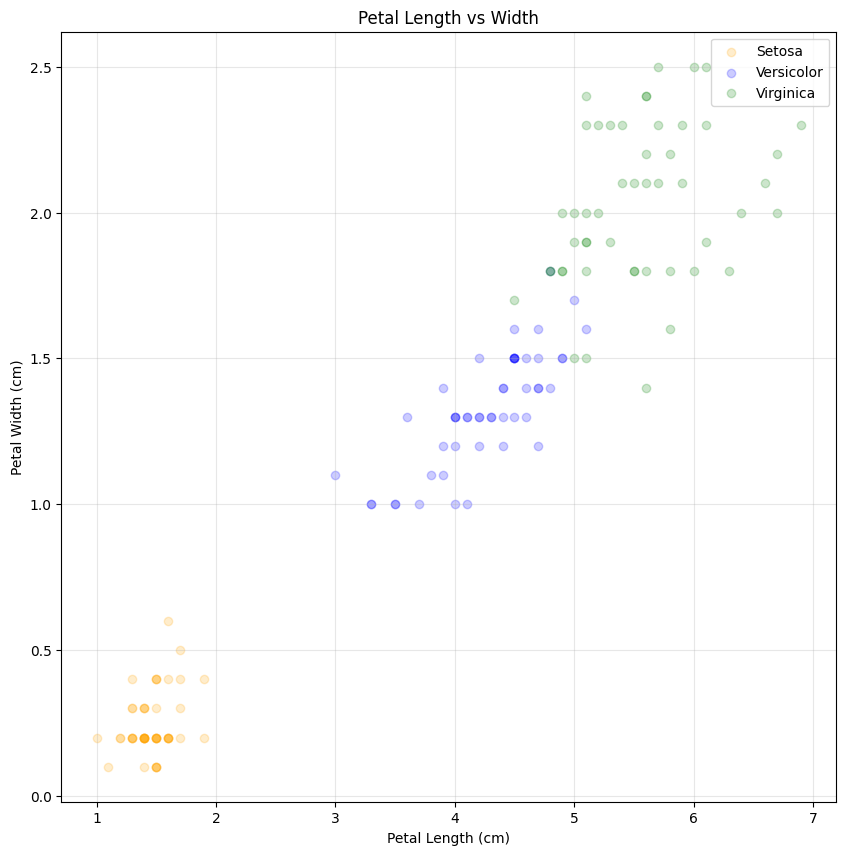

In [5]:
fig, axes = plt.subplots(figsize=(10, 10))

setosa = df[df['Species'] == 'Iris-setosa']
versicolor = df[df['Species'] == 'Iris-versicolor']
virginica = df[df['Species'] == 'Iris-virginica']

axes.scatter(setosa['PetalLengthCm'], setosa['PetalWidthCm'], 
           color='orange', label='Setosa', alpha=0.2)
axes.scatter(versicolor['PetalLengthCm'], versicolor['PetalWidthCm'], 
           color='blue', label='Versicolor', alpha=0.2)
axes.scatter(virginica['PetalLengthCm'], virginica['PetalWidthCm'], 
           color='green', label='Virginica', alpha=0.2)

# Настройка
axes.set_xlabel("Petal Length (cm)")
axes.set_ylabel("Petal Width (cm)")
axes.set_title("Petal Length vs Width")
axes.legend()
axes.grid(True, alpha=0.3)

plt.show()

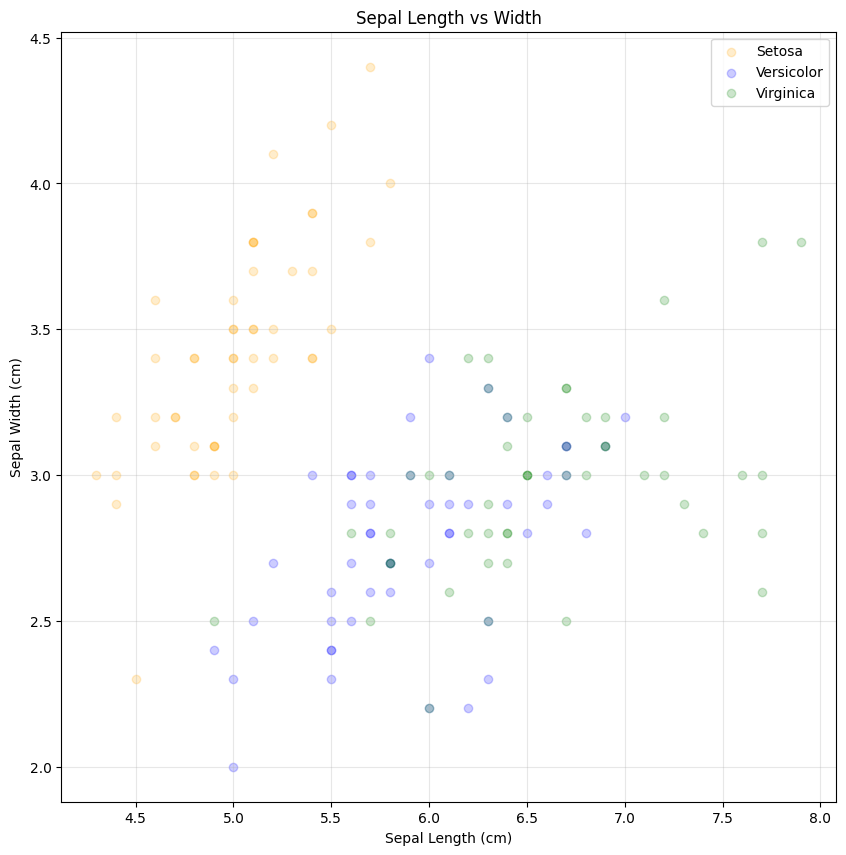

In [6]:
fig, axes = plt.subplots(figsize=(10, 10))

setosa = df[df['Species'] == 'Iris-setosa']
versicolor = df[df['Species'] == 'Iris-versicolor']
virginica = df[df['Species'] == 'Iris-virginica']

axes.scatter(setosa['SepalLengthCm'], setosa['SepalWidthCm'], 
           color='orange', label='Setosa', alpha=0.2)
axes.scatter(versicolor['SepalLengthCm'], versicolor['SepalWidthCm'], 
           color='blue', label='Versicolor', alpha=0.2)
axes.scatter(virginica['SepalLengthCm'], virginica['SepalWidthCm'], 
           color='green', label='Virginica', alpha=0.2)

# Настройка
axes.set_xlabel("Sepal Length (cm)")
axes.set_ylabel("Sepal Width (cm)")
axes.set_title("Sepal Length vs Width")
axes.legend()
axes.grid(True, alpha=0.3)

plt.show()

In [7]:
# Функция для отображения границ решения
def plot_decision_boundaries(X, y, model, ax=None, title="Decision Boundaries", fx = 'Признак x', fy = 'Признак y'):

    print(type(X))

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Определяем границы графика с небольшим запасом
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Создаем сетку точек для построения границы
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Предсказываем класс для каждой точки сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Определяем цветовую схему
    colors = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

    # Отображаем границы решения
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=colors)

    # Отображаем обучающие точки
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=80, edgecolor='k', cmap=colors)

    # Добавляем легенду
    legend1 = ax.legend(*scatter.legend_elements(), title="Классы")
    ax.add_artist(legend1)

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)

    return ax

#  Визуализация влияния на модель гиперпараметров

In [8]:
f1_i = 2 # Индексы 2 признаков для построения графика
f2_i = 3

X_train_2d = X_train_scaled[:, [f1_i, f2_i]] # непосредственно 2 признака для построения графика
X_test_2d = X_test_scaled[:, [f1_i, f2_i]]

f1_i_t = df.columns[f1_i] # названия этих 2 признаков
f2_i_t = df.columns[f2_i]


# энкодим таргет
le = LabelEncoder() 

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


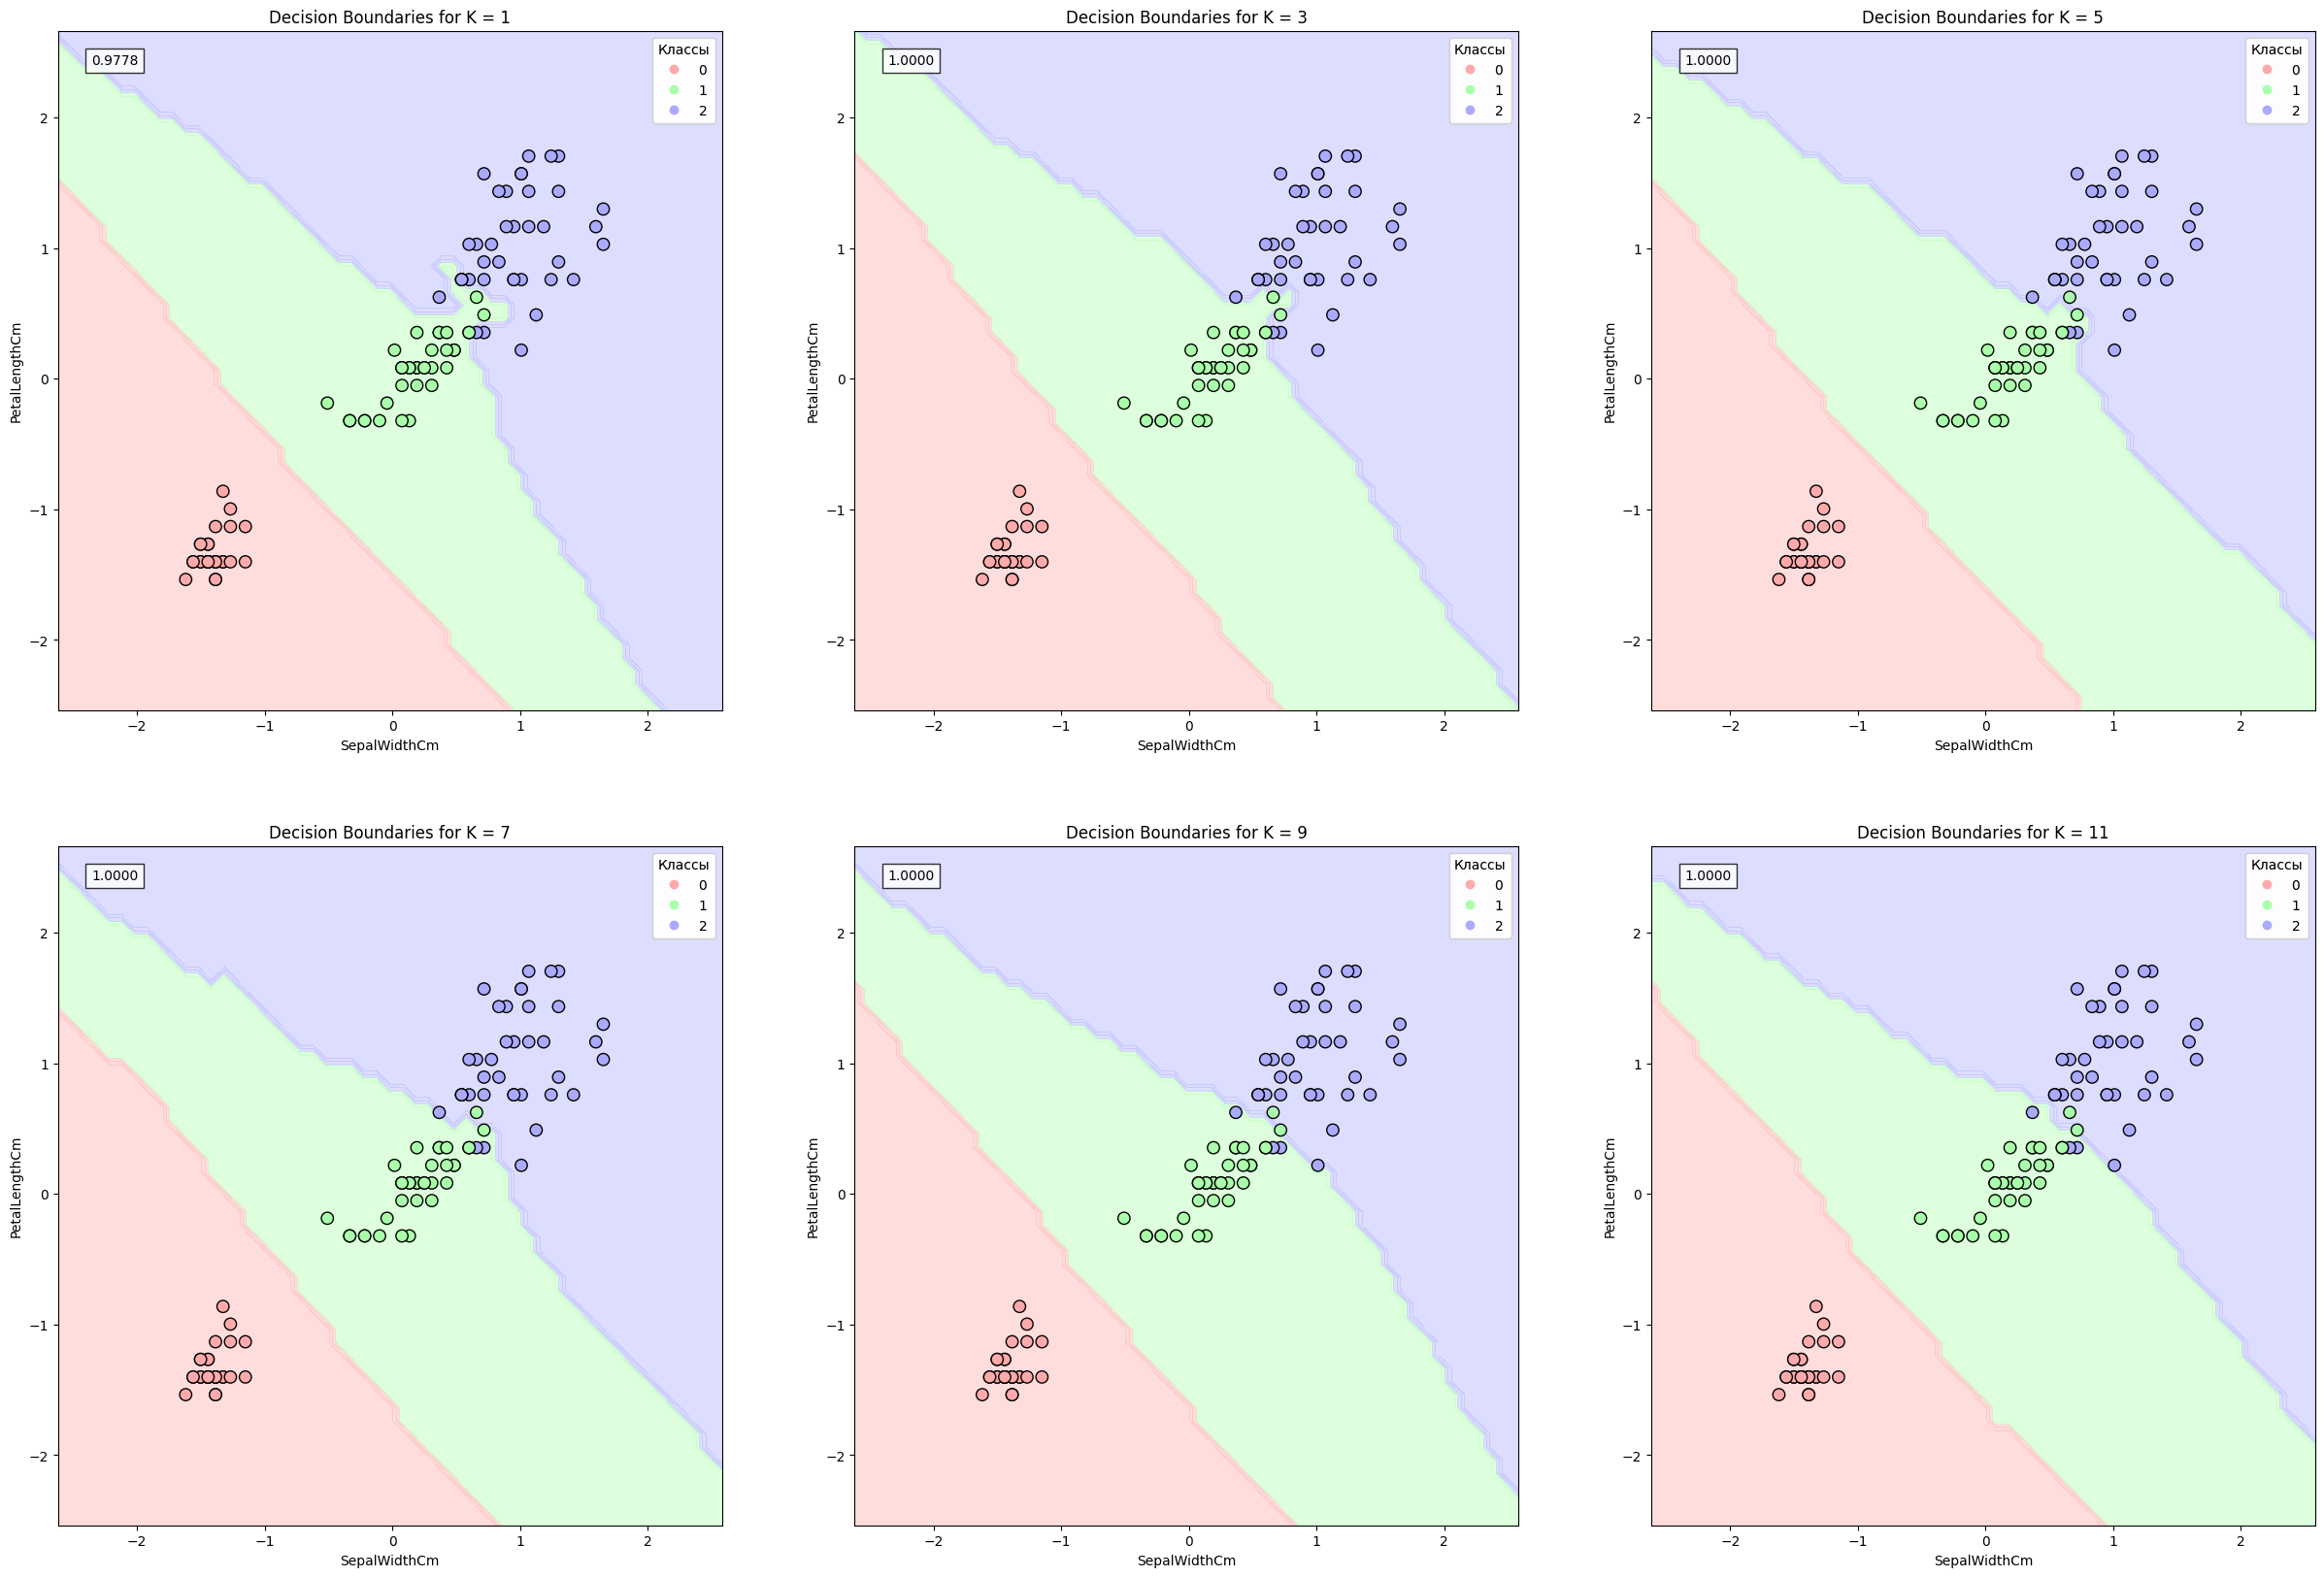

In [9]:
fig, axes = plt.subplots(2, 3, figsize = (30, 20))


counter_x = 0
counter_y = 0

for i in range(6):
    model_full = KNeighborsClassifier(n_neighbors=i*2+1)
    model_full.fit(X_train_scaled, y_train_enc)

    model_vis = KNeighborsClassifier(n_neighbors=i*2+1)
    model_vis.fit(X_train_2d, y_train_enc)

    title = "Decision Boundaries for K = " + str(i*2+1)

    plot_decision_boundaries(X_train_2d, y_train_enc, model_vis, ax=axes[counter_y][counter_x%3], title=title, fx=f1_i_t, fy=f2_i_t)

    accuracy = model_full.score(X_test_scaled, y_test_enc)

    axes[counter_y][counter_x%3].text(0.05, 0.95, f'{accuracy:.4f}', transform=axes[counter_y, counter_x%3].transAxes, bbox=dict(facecolor='white', alpha=0.8))

    if counter_x%3 == 2:
         counter_y +=1
    counter_x += 1


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


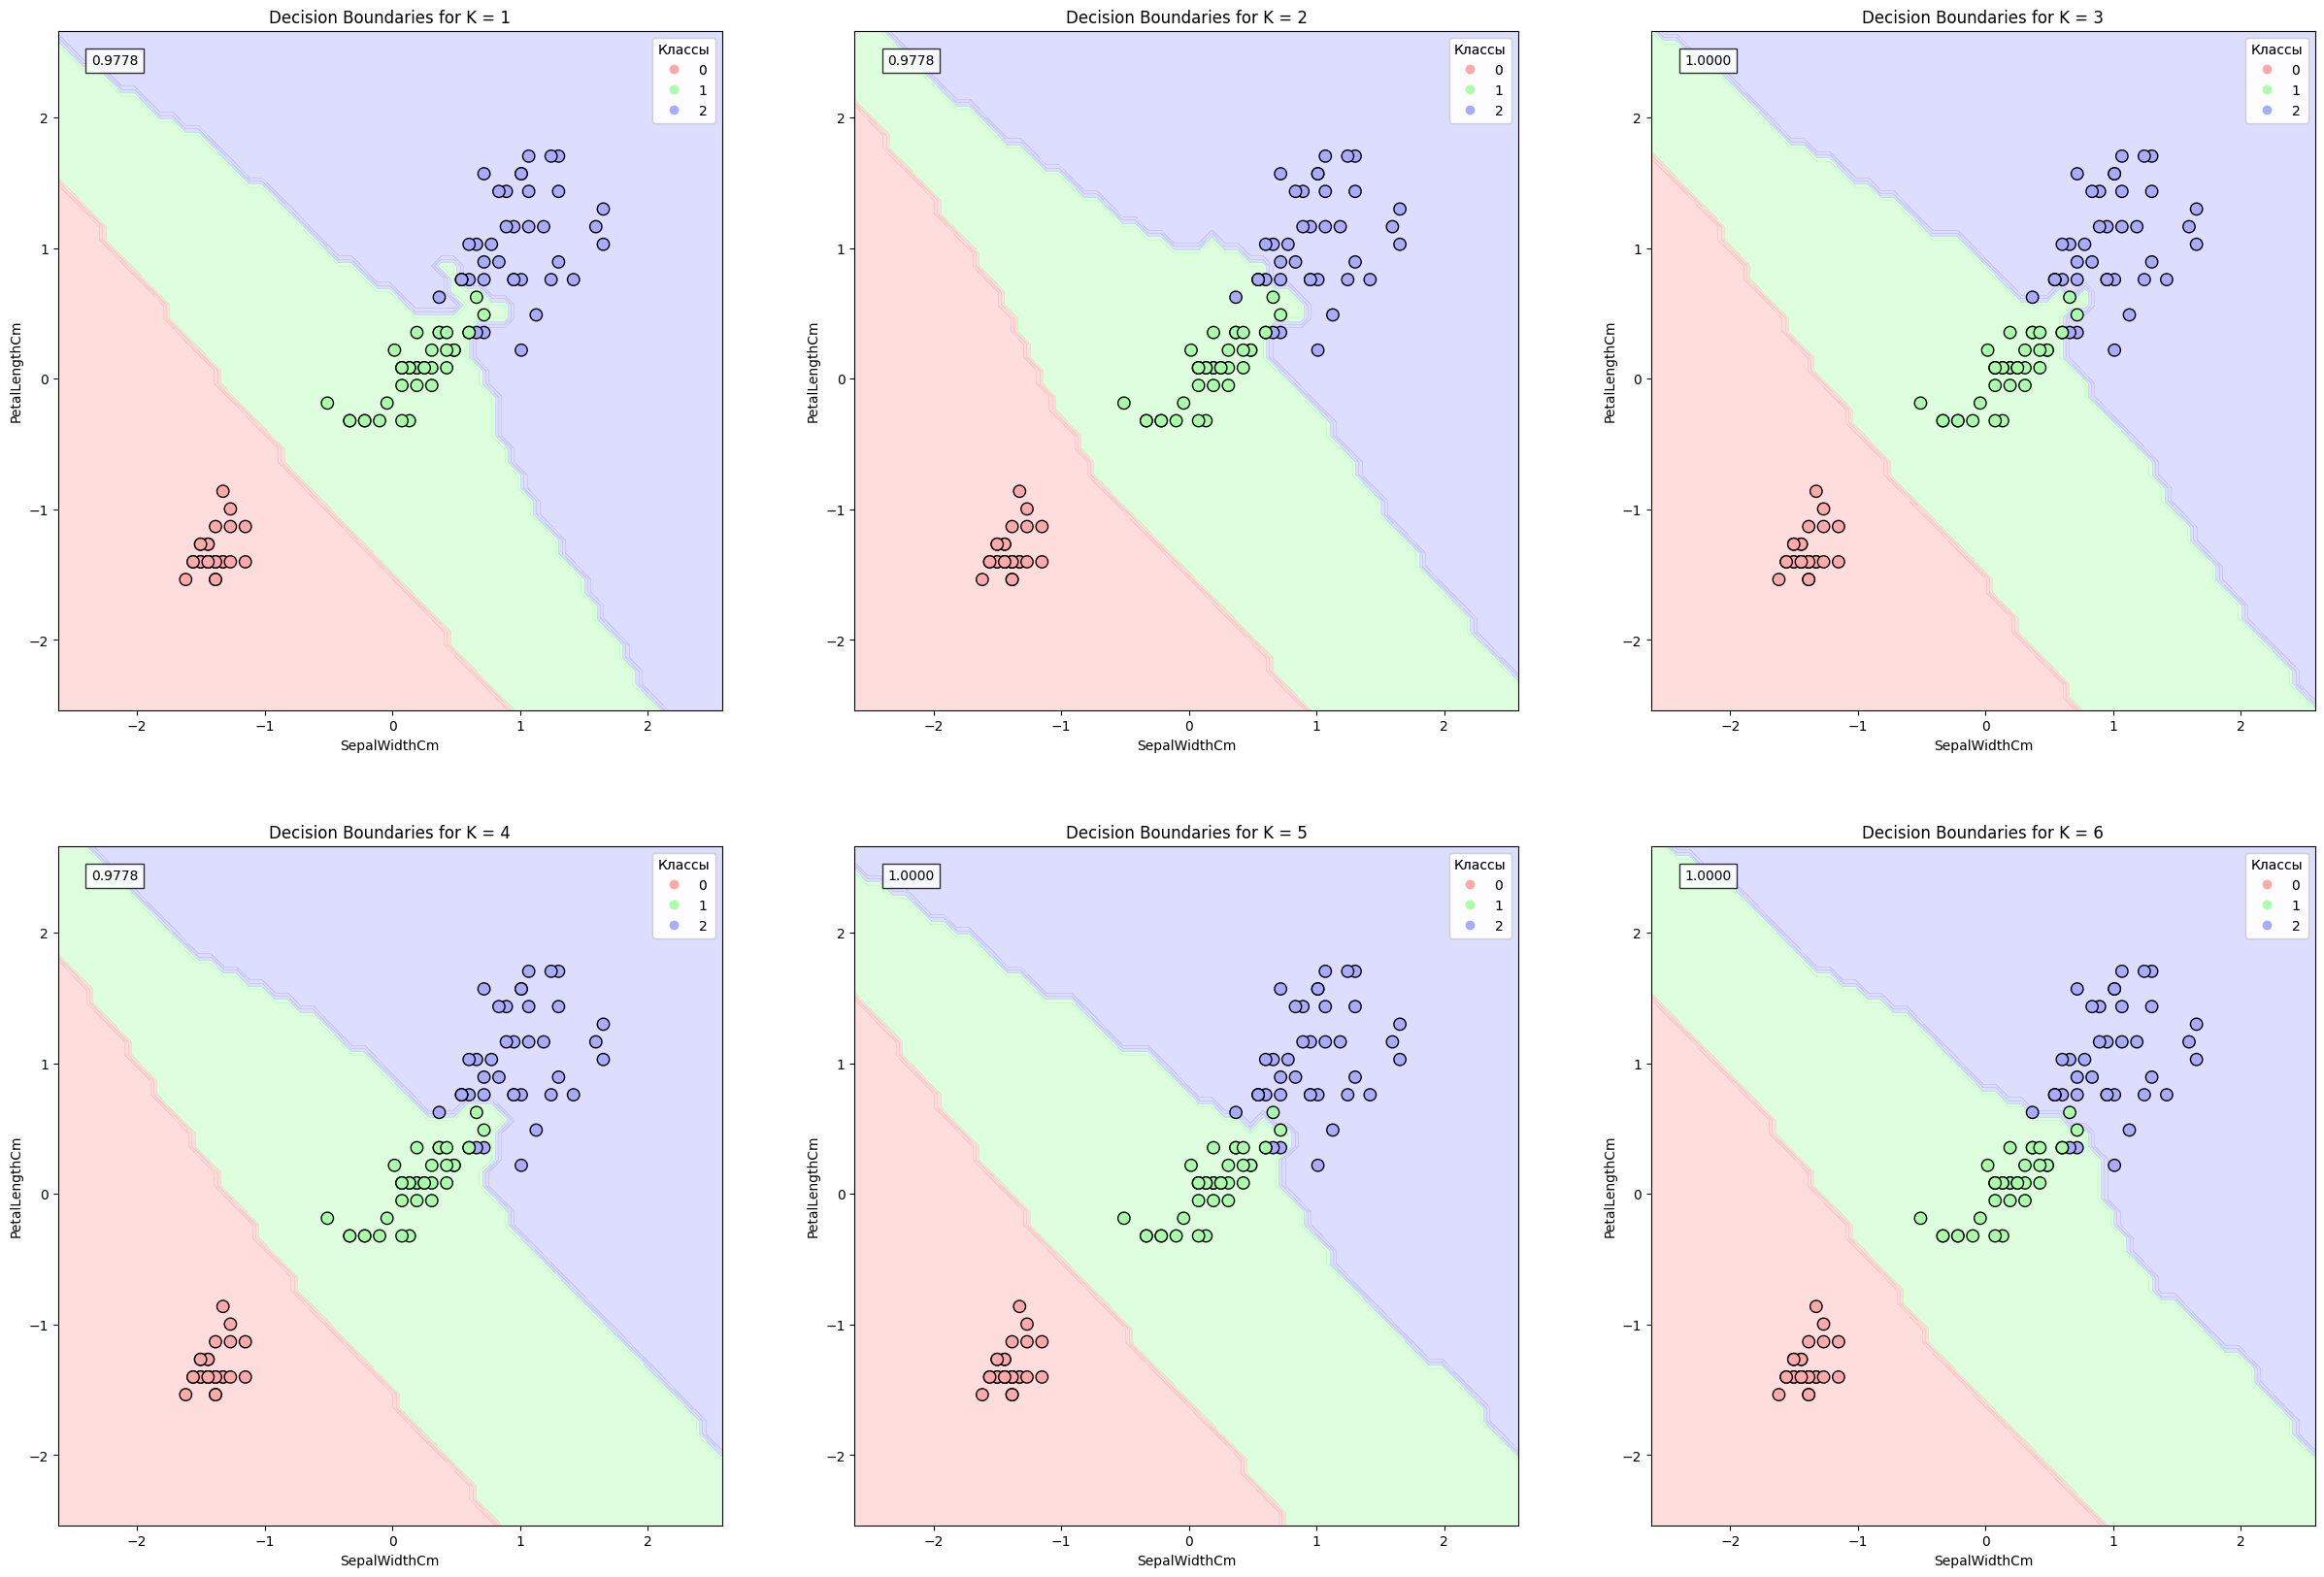

In [10]:
fig, axes = plt.subplots(2, 3, figsize = (30, 20))


counter_x = 0
counter_y = 0

for i in range(6):
    model_full = KNeighborsClassifier(n_neighbors=i+1)
    model_full.fit(X_train_scaled, y_train_enc)

    model_vis = KNeighborsClassifier(n_neighbors=i+1)
    model_vis.fit(X_train_2d, y_train_enc)

    title = "Decision Boundaries for K = " + str(i+1)

    plot_decision_boundaries(X_train_2d, y_train_enc, model_vis, ax=axes[counter_y][counter_x%3], title=title, fx=f1_i_t, fy=f2_i_t)

    accuracy = model_full.score(X_test_scaled, y_test_enc)

    axes[counter_y][counter_x%3].text(0.05, 0.95, f'{accuracy:.4f}', transform=axes[counter_y, counter_x%3].transAxes, bbox=dict(facecolor='white', alpha=0.8))

    if counter_x%3 == 2:
         counter_y +=1
    counter_x += 1


Видно, что модель с K = 1, явно переобучилась, т.к. видны рваные границы, а с K = 12 недообучилась, т.к. плохо разделяет классы.

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Text(0.05, 0.95, '1.0000')

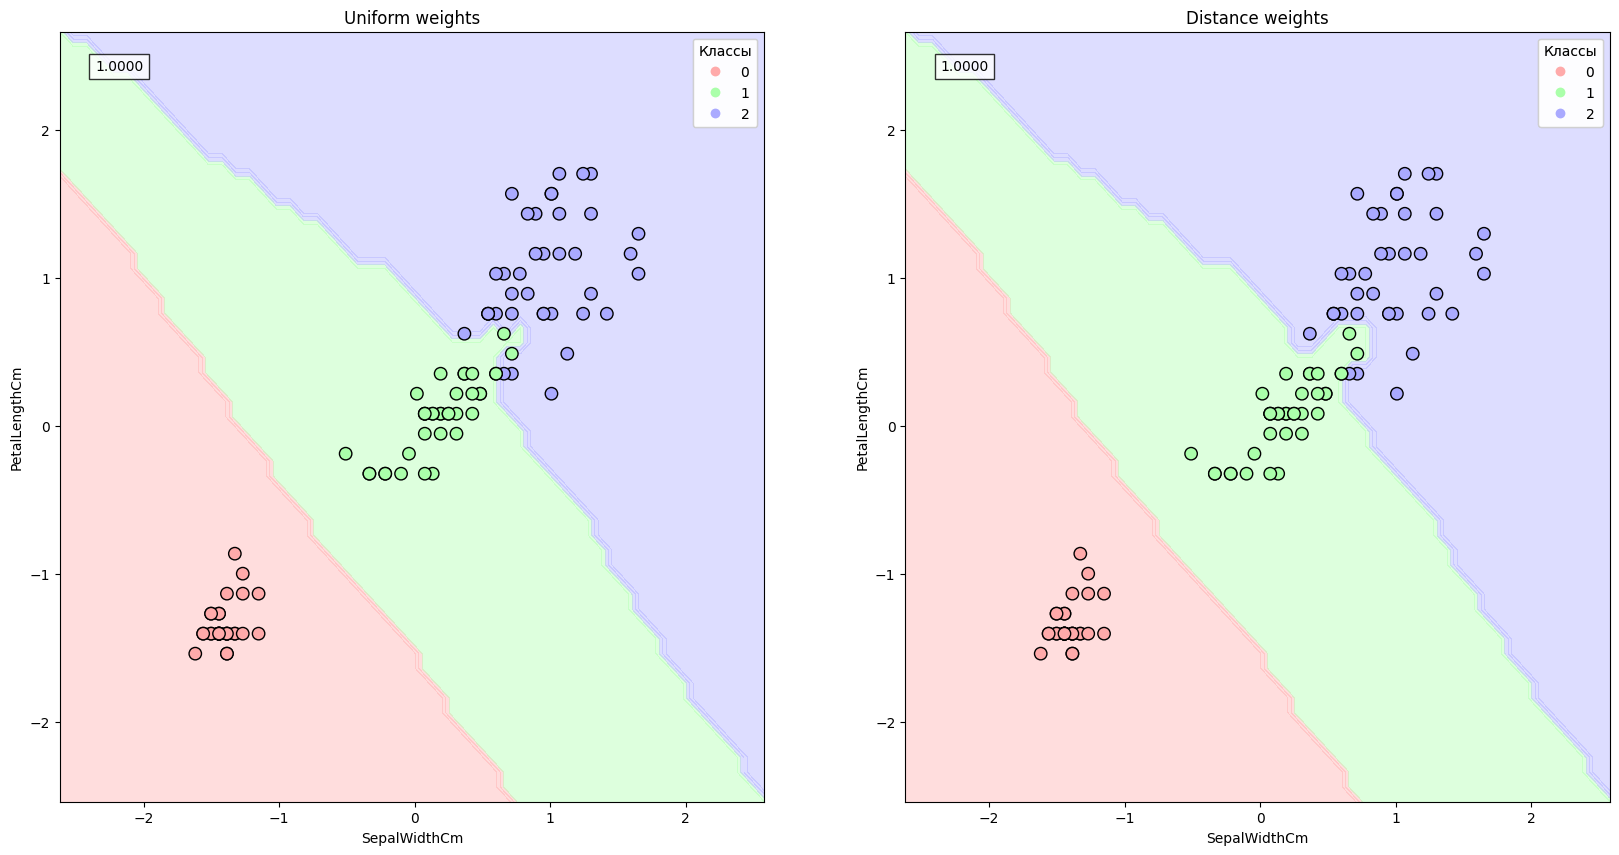

In [11]:
fig, axes = plt.subplots(1, 2, figsize = (20, 10))

n_neighbors = 3 

# UNIFORM

model_full = KNeighborsClassifier(n_neighbors=n_neighbors, weights='uniform')
model_full.fit(X_train_scaled, y_train_enc)

model_vis = KNeighborsClassifier(n_neighbors=n_neighbors, weights='uniform')
model_vis.fit(X_train_2d, y_train_enc)

title = "Uniform weights"

plot_decision_boundaries(X_train_2d, y_train_enc, model_vis, ax=axes[0], title=title, fx=f1_i_t, fy=f2_i_t)

accuracy = model_full.score(X_test_scaled, y_test_enc)

axes[0].text(0.05, 0.95, f'{accuracy:.4f}', transform=axes[0].transAxes, bbox=dict(facecolor='white', alpha=0.8))

# DISTANCE

model_full = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance')
model_full.fit(X_train_scaled, y_train_enc)

model_vis = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance')
model_vis.fit(X_train_2d, y_train_enc)

title = "Distance weights"

plot_decision_boundaries(X_train_2d, y_train_enc, model_vis, ax=axes[1], title=title, fx=f1_i_t, fy=f2_i_t)

accuracy = model_full.score(X_test_scaled, y_test_enc)

axes[1].text(0.05, 0.95, f'{accuracy:.4f}', transform=axes[1].transAxes, bbox=dict(facecolor='white', alpha=0.8))



Изменения не такие, значительные, но видно, что веса distance показывают себя лучше.

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


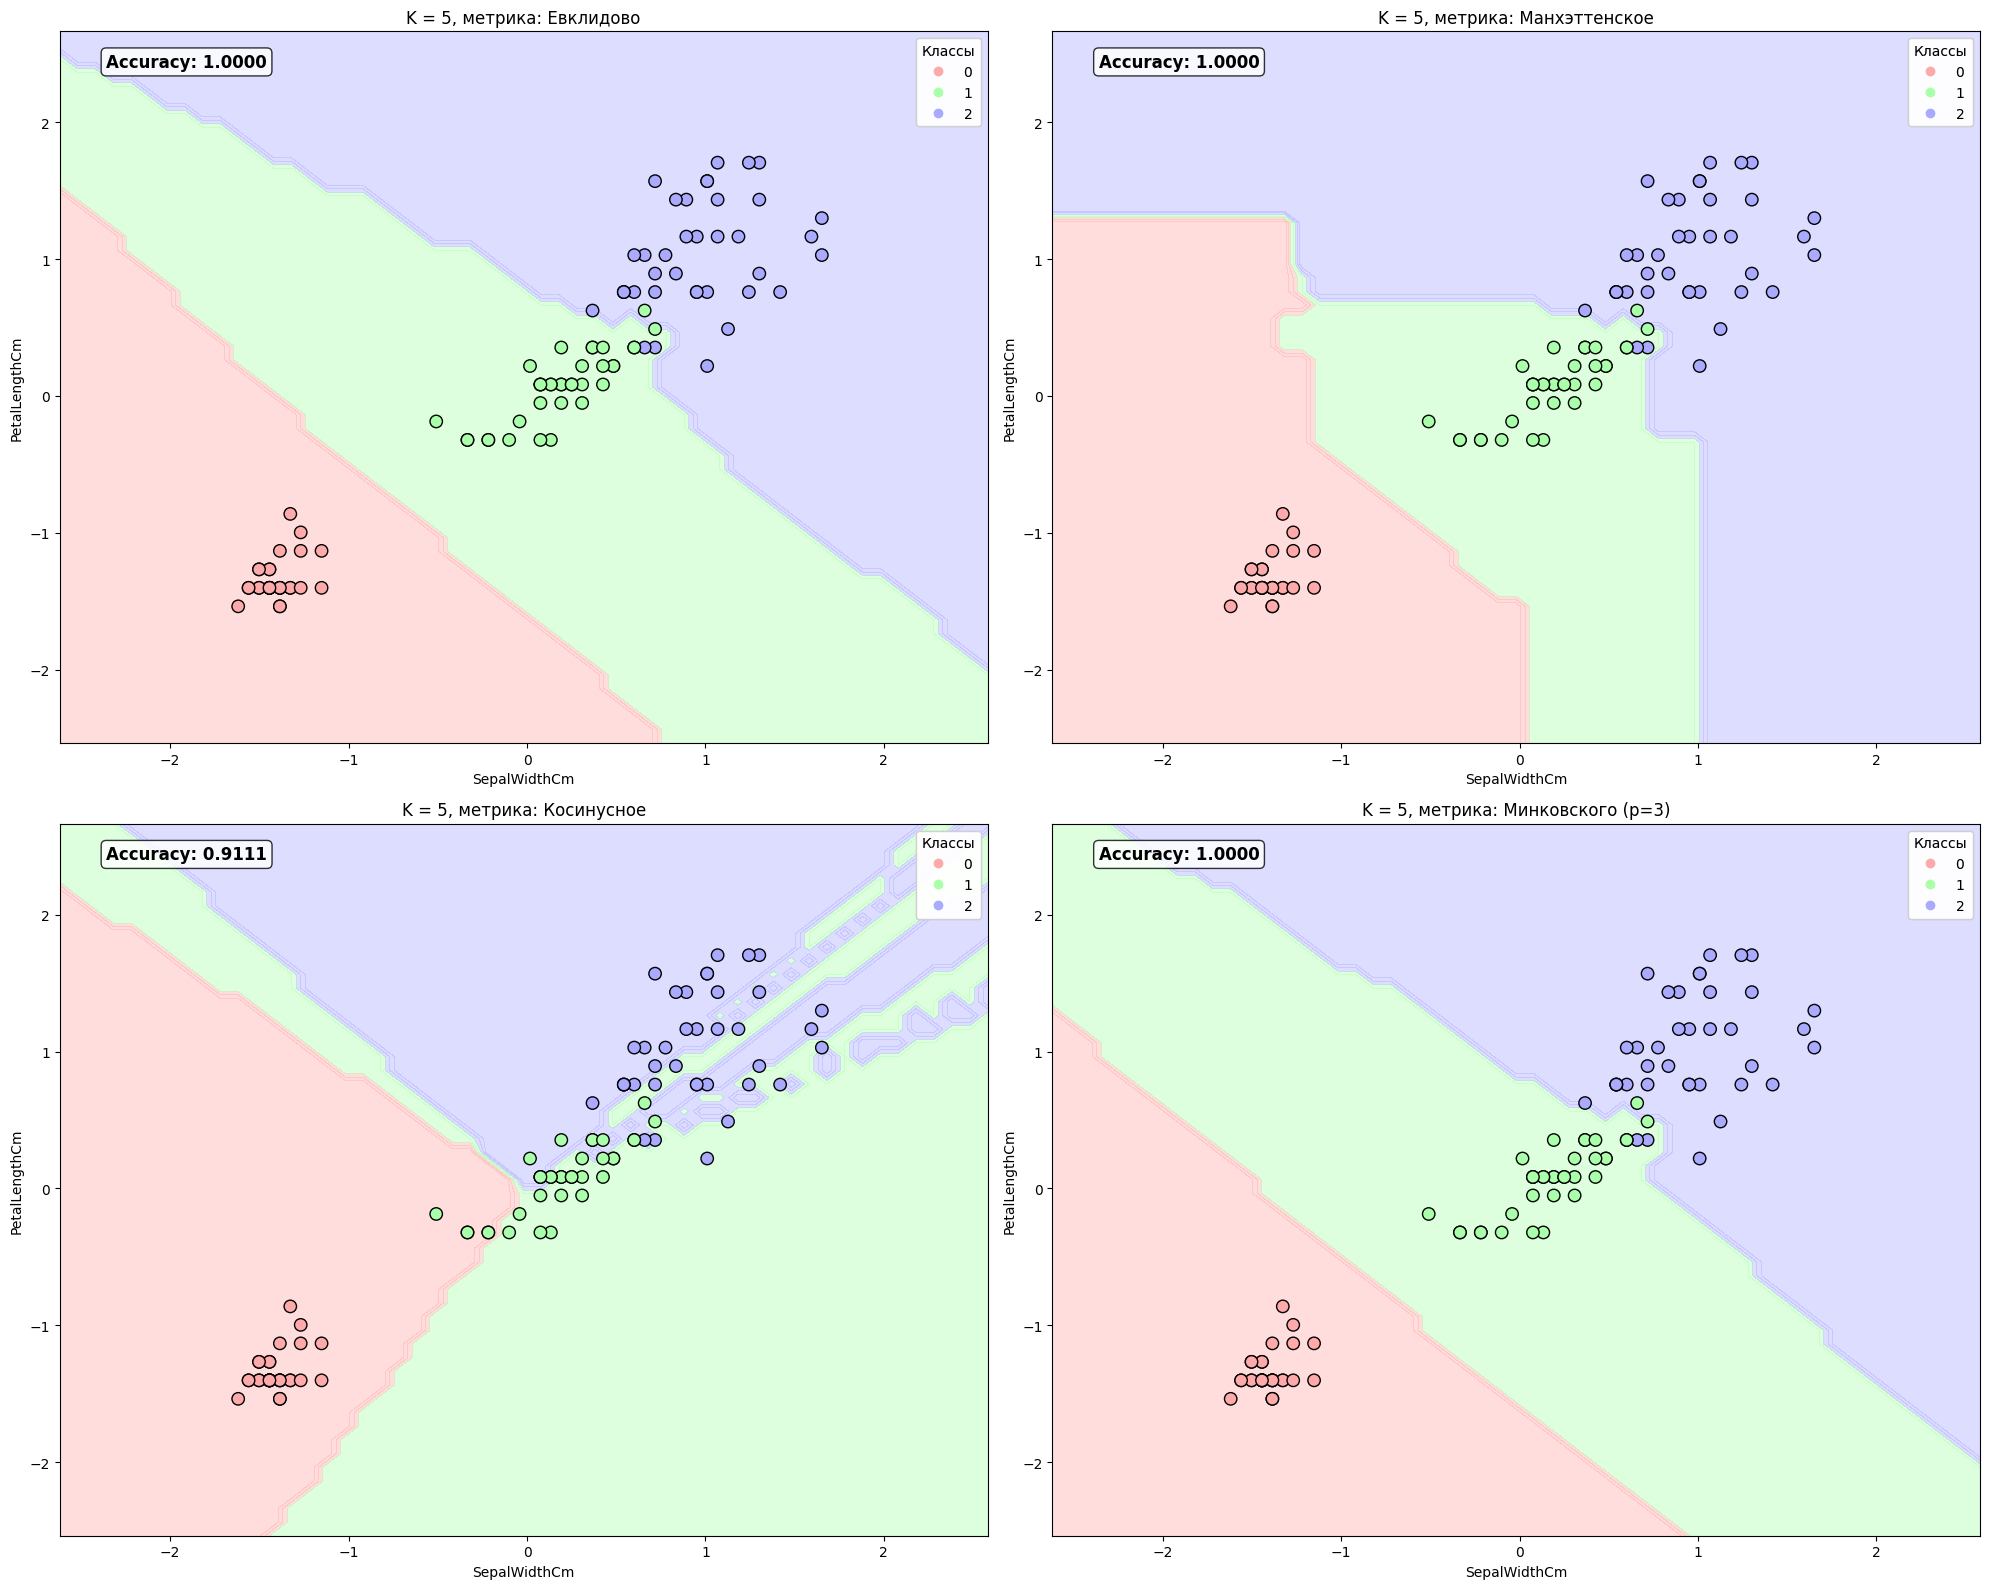

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Метрики для визуализации (заменил chebyshev на cosine)
metrics = ['euclidean', 'manhattan', 'cosine', 'minkowski']
metric_names = {
    'euclidean': 'Евклидово',
    'manhattan': 'Манхэттенское', 
    'cosine': 'Косинусное',
    'minkowski': 'Минковского (p=3)'
}

k = 5

for idx, metric in enumerate(metrics):
    row, col = idx // 2, idx % 2
    
    # Создаем модель с нужной метрикой
    if metric == 'minkowski':
        model_full = KNeighborsClassifier(n_neighbors=k, metric=metric, p=3)
        model_vis = KNeighborsClassifier(n_neighbors=k, metric=metric, p=3)
    else:
        model_full = KNeighborsClassifier(n_neighbors=k, metric=metric)
        model_vis = KNeighborsClassifier(n_neighbors=k, metric=metric)
    
    # Обучаем
    model_full.fit(X_train_scaled, y_train_enc)
    model_vis.fit(X_train_2d, y_train_enc)
    
    # Визуализация
    title = f"K = {k}, метрика: {metric_names[metric]}"
    plot_decision_boundaries(X_train_2d, y_train_enc, model_vis, 
                            ax=axes[row, col], title=title,
                            fx=f1_i_t, fy=f2_i_t)
    
    # Accuracy
    accuracy = model_full.score(X_test_scaled, y_test_enc)
    
    # Текст
    axes[row, col].text(0.05, 0.95, f'Accuracy: {accuracy:.4f}',
                       transform=axes[row, col].transAxes,
                       bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'),
                       fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## А почему нельзя подбирать параметры на тестовой выборке?
    Т.к. нельзя обучать модель на тестовых данных, тестовые данные и нужны для того чтобы оценить как будет вести себя модель в условно незнакомой ситуации, а если обучить её на тестовой выборке она просто "запомнит правильные ответы" и покажет результат 100 или близкий к нему, но при использовании на других данных такая модель с высокой вероятностью не будет давать корректных ответов.

# Подбор гиперпараметров

In [27]:
model = KNeighborsClassifier()

param_grid = {
    'n_neighbors': range(1, 20),  # просто имя параметра
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'cosine']
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy'
)
   
grid_search.fit(X_train_scaled, y_train_enc)

# 5. Результаты
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая CV-точность:", grid_search.best_score_)

# 6. Проверка на тесте
test_score = grid_search.score(X_test_scaled, y_test_enc)
print("Точность на тесте:", test_score)


Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Лучшая CV-точность: 0.9428571428571428
Точность на тесте: 1.0


In [23]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)


print(classification_report(y_test_enc, y_pred, target_names=y_train.unique()))

                 precision    recall  f1-score   support

Iris-versicolor       1.00      1.00      1.00        19
 Iris-virginica       1.00      1.00      1.00        13
    Iris-setosa       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



Итог: KNN идеально разделил датасет на классы с k=3, евклидовой метрикой и uniform весами.